<a href="https://colab.research.google.com/github/gowrignair21-ai/Machine-Learning-Prjct/blob/main/Day_6_Activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv("/content/fish.csv")

In [5]:
df

,Bream,242.0,23.2,25.4,30.0,38.4,13.4
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2
...,...,...,...,...,...,...,...
79,Pike,950.0,48.3,51.7,55.1,16.2,11.2
80,Pike,1250.0,52.0,56.0,59.7,17.9,11.7
81,Pike,1600.0,56.0,60.0,64.0,15.0,9.6
82,Pike,1550.0,56.0,60.0,64.0,15.0,9.6


In [6]:
df.shape

(84, 7)

In [7]:
df.describe()

,242.0,23.2,25.4,30.0,38.4,13.4
count,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000
mean,434.017857,27.388095,29.607143,33.157143,27.953571,12.859524
std,382.648669,11.348058,12.249630,13.272086,10.351142,2.129377
min,0.000000,9.300000,9.800000,10.800000,14.500000,8.700000
25%,120.000000,19.325000,20.950000,23.550000,16.875000,10.875000
50%,390.000000,28.450000,30.850000,35.050000,26.900000,13.700000
75%,657.500000,32.725000,36.000000,40.675000,39.225000,14.700000
max,1650.000000,59.000000,63.400000,68.000000,44.500000,16.100000


In [8]:
df.rename(columns={'Bream':'Species',
                    '242.0':'Weight',
                    '23.2':'Length1',
                    '25.4':'Length2',
                    '30.0':'Length3',
                    '38.4':'Height',
                    '13.4':'Width'},inplace=True)
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2


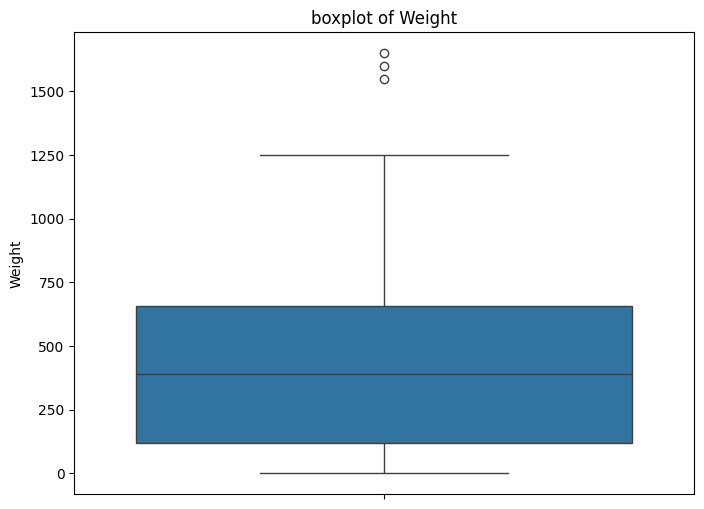

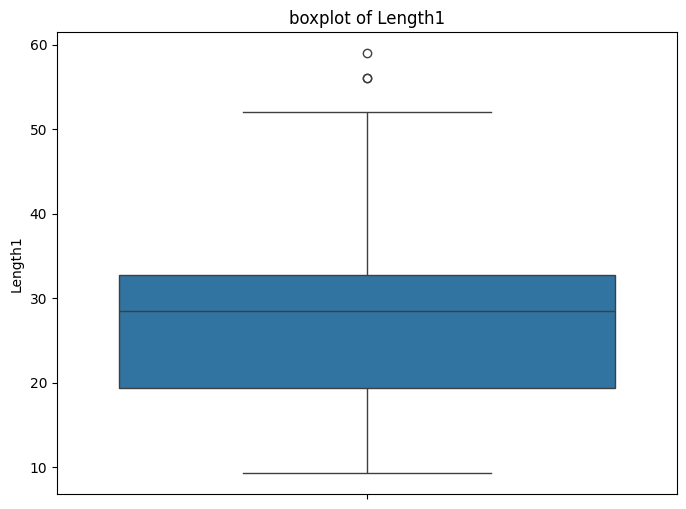

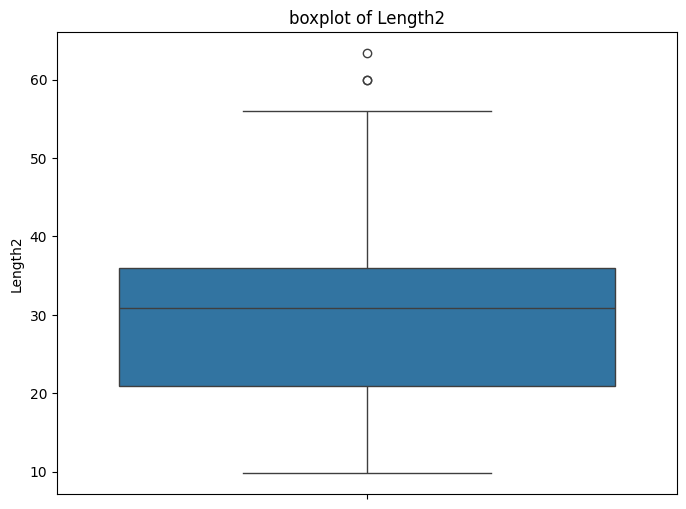

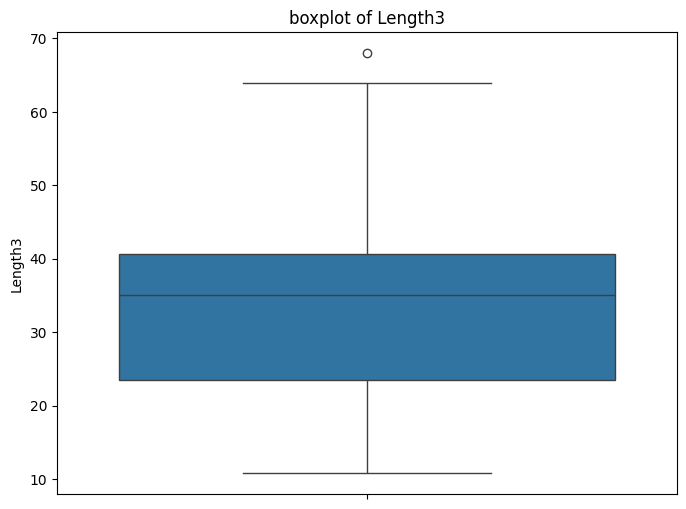

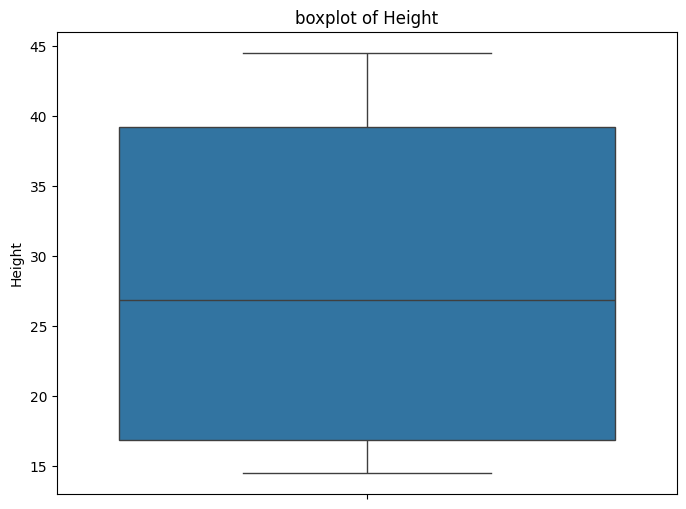

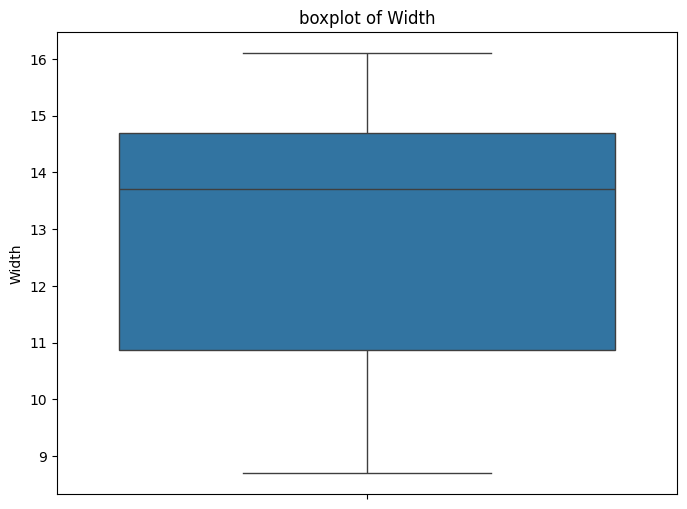

In [11]:
import seaborn as sns
#Outlier detection
num_cols=df.select_dtypes(include=np.number).columns
num_cols
for col in num_cols:
  plt.figure(figsize=(8,6))
  sns.boxplot(df[col])
  plt.title(f'boxplot of {col}')
  plt.show()

In [14]:
#Winsorize method
from scipy.stats.mstats import winsorize
for col in ['Weight','Length1','Length2','Length3']:
  df[col]=winsorize(df[col],[0,0.05])

In [15]:
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2
...,...,...,...,...,...,...,...
79,Pike,950.0,48.3,51.7,55.1,16.2,11.2
80,Pike,1000.0,48.3,51.7,55.1,17.9,11.7
81,Pike,1000.0,48.3,51.7,55.1,15.0,9.6
82,Pike,1000.0,48.3,51.7,55.1,15.0,9.6


<Axes: ylabel='Weight'>

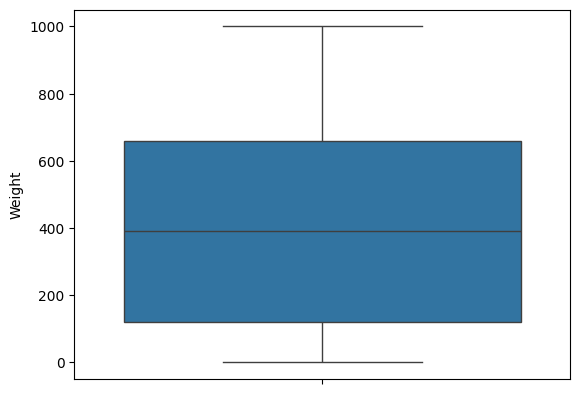

In [16]:
 sns.boxplot(y=df['Weight'])

<Axes: ylabel='Length1'>

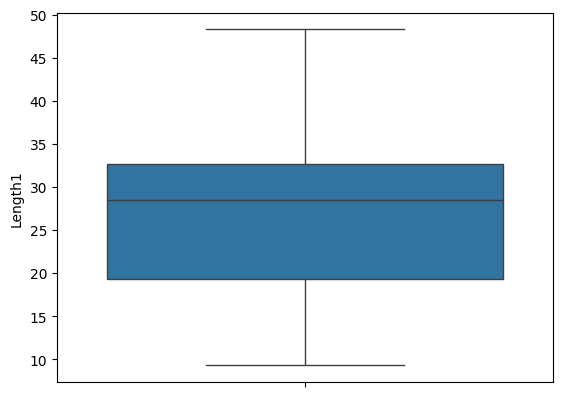

In [17]:
 sns.boxplot(y=df['Length1'])

<Axes: ylabel='Length2'>

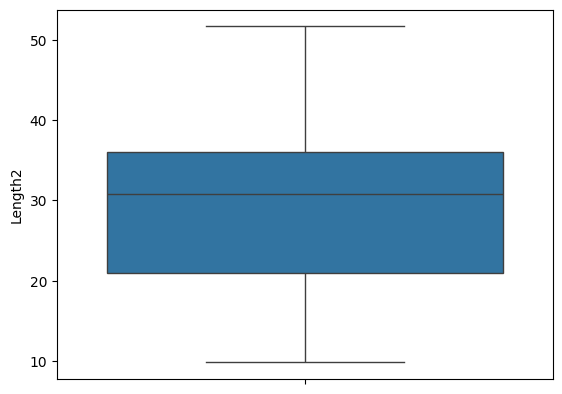

In [18]:
sns.boxplot(y=df['Length2'])

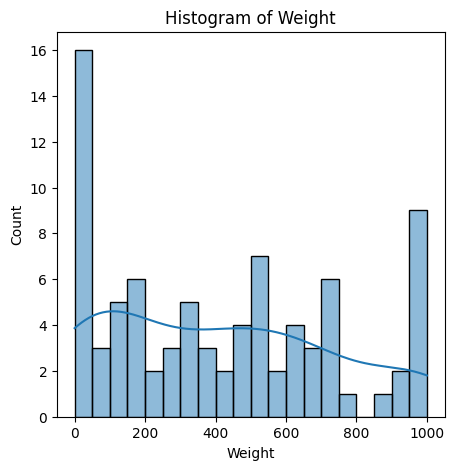

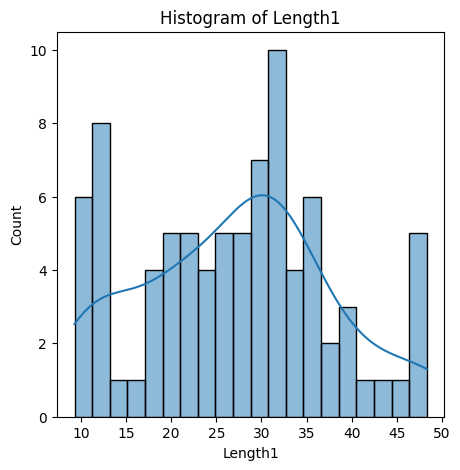

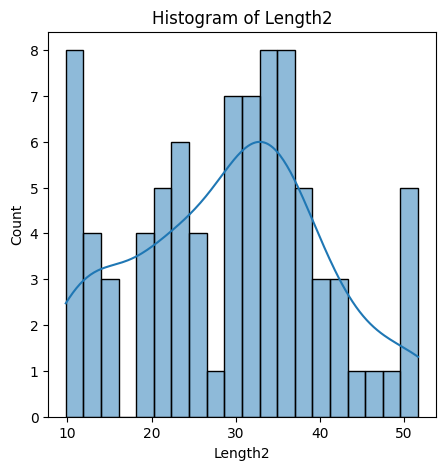

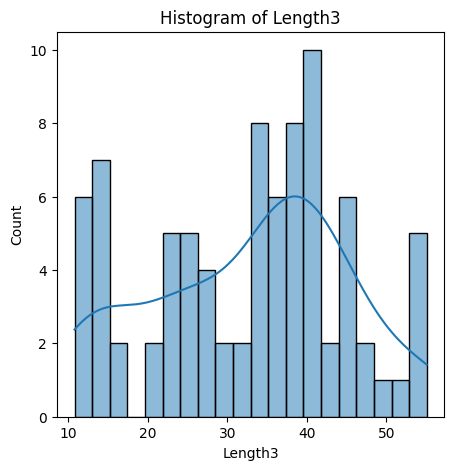

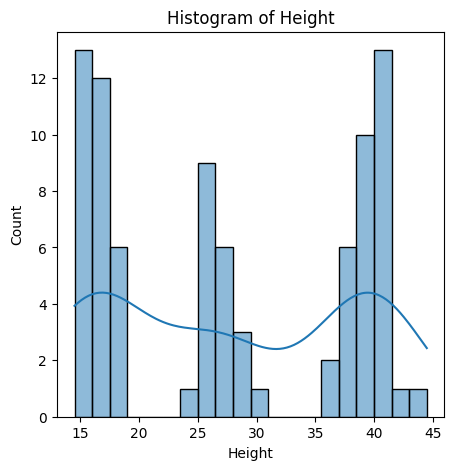

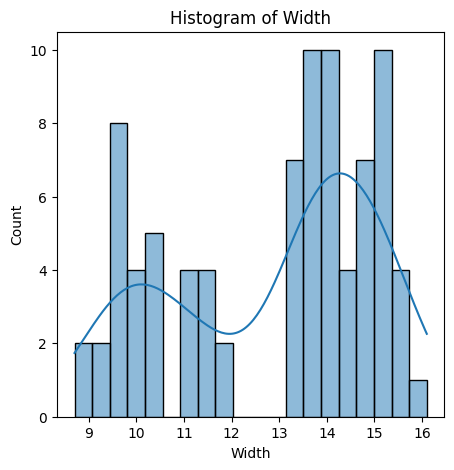

In [19]:
num_cols=df.select_dtypes(include=np.number).columns
for col in num_cols:
  plt.figure(figsize=(5,5))
  sns.histplot(df[col],kde=True,bins=20)
  plt.title(f'Histogram of {col}')
  plt.show()

In [20]:
from scipy.stats import skew
df['Weight'].skew()

np.float64(0.37029728679944923)

In [21]:
from scipy.stats import skew
df['Length1'].skew()

np.float64(0.11161429735602048)

In [22]:
from scipy.stats import skew
df['Length2'].skew()

np.float64(0.04001481928200505)

In [23]:
from scipy.stats import skew
df['Length3'].skew()

np.float64(-0.19938376068046204)

<Axes: >

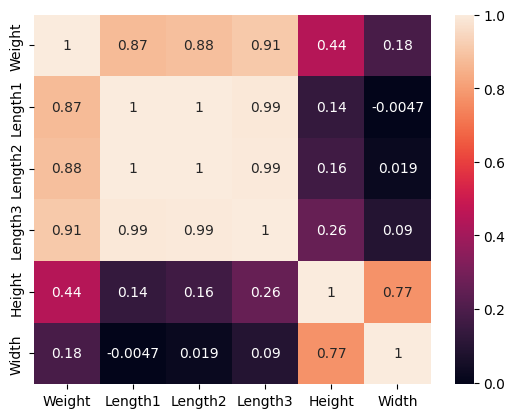

In [24]:
import seaborn as sns
data=df.drop(columns=['Species'])
sns.heatmap(data.corr(),annot=True)

<Axes: xlabel='Weight', ylabel='Length2'>

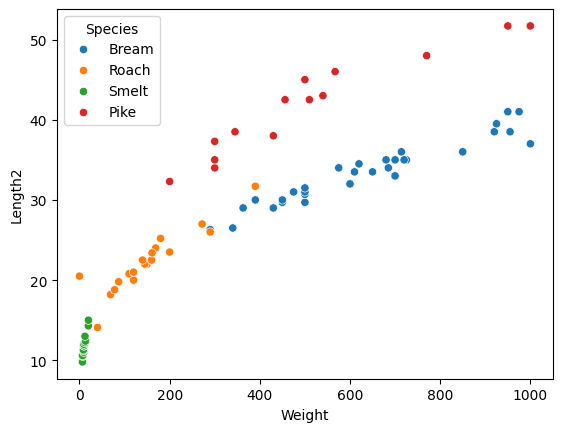

In [25]:
sns.scatterplot(data=df,x='Weight',y='Length2',hue='Species')

In [26]:
#Standard Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(data)
X_scaled

array([[-0.37307155, -0.29008277, -0.2585373 , -0.12494199,  1.1707675 ,
         0.44432002],
       [-0.21712226, -0.29964594, -0.24082349, -0.13307145,  1.15132991,
         1.05849403],
       [-0.14538559, -0.0701299 , -0.01940084,  0.06203549,  0.97639163,
         0.20809925],
       [ 0.06358647, -0.05100356, -0.01940084,  0.10268277,  0.84032853,
         1.05849403],
       [ 0.12596619, -0.02231406,  0.0425975 ,  0.15958896,  1.09301715,
         0.63329664],
       [ 0.28191548, -0.02231406,  0.0425975 ,  0.14333005,  1.27767423,
         1.15298234],
       [-0.06117297,  0.05419129,  0.06916822,  0.18397733,  0.80145335,
         0.25534341],
       [ 0.12596619,  0.05419129,  0.06916822,  0.19210678,  1.16104871,
         0.44432002],
       [ 0.28191548,  0.1402598 ,  0.13116656,  0.2815308 ,  1.10273595,
         0.39707587],
       [ 0.20394083,  0.13069663,  0.15773727,  0.2815308 ,  1.11245474,
         0.58605249],
       [ 0.28191548,  0.15938614,  0.15773727,  0.

In [27]:
# K-Mean clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
wcss=[]
sil_scores=[]
for k in range(2,11):
  kmeans=KMeans(n_clusters=k,
                random_state=42,
                init='k-means++',
                max_iter=300,
                n_init=10)
  kmeans.fit_predict(X_scaled)
  labels=kmeans.labels_
  wcss.append(kmeans.inertia_)
  sil_h=silhouette_score(X_scaled,labels)
  sil_scores.append(sil_h)

In [28]:
for i,k in enumerate(range(2,11)):
  print(f'for k={k},wcss={wcss[i]:.2f} and sil_scores={sil_scores[i]:.2f}')

for k=2,wcss=257.49 and sil_scores=0.45
for k=3,wcss=135.04 and sil_scores=0.54
for k=4,wcss=75.24 and sil_scores=0.59
for k=5,wcss=51.81 and sil_scores=0.60
for k=6,wcss=36.16 and sil_scores=0.53
for k=7,wcss=30.41 and sil_scores=0.53
for k=8,wcss=25.31 and sil_scores=0.52
for k=9,wcss=21.01 and sil_scores=0.46
for k=10,wcss=18.50 and sil_scores=0.46


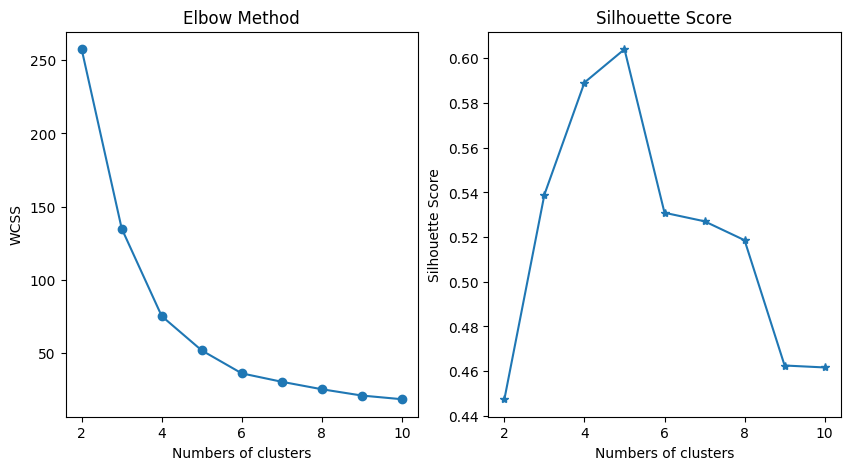

In [29]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(range(2,11),wcss,marker='o')
plt.title('Elbow Method')
plt.xlabel('Numbers of clusters')
plt.ylabel('WCSS')

plt.subplot(1,2,2)
plt.plot(range(2,11),sil_scores,marker='*')
plt.title('Silhouette Score')
plt.xlabel('Numbers of clusters')
plt.ylabel('Silhouette Score')
plt.show()

In [30]:
kmeans=KMeans(n_clusters=5,
                random_state=42,
                init='k-means++',
                max_iter=300,
                n_init=10)
kmeans.fit(X_scaled)
cluster_labels= kmeans.predict(X_scaled)
cluster_labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1,
       3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4], dtype=int32)

In [31]:
df['kmeans_cluster']=cluster_labels
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width,kmeans_cluster
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8,0
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1,0
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3,0
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1,0
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2,0


In [32]:
df['kmeans_cluster'].value_counts()

,count
kmeans_cluster,
0,34
1,20
3,13
2,11
4,6


In [33]:
new_fish=np.array([[20,300,20,20,20,20]])
scaled= scaler.transform(new_fish)
cluster=kmeans.predict(scaled)
cluster

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([4], dtype=int32)

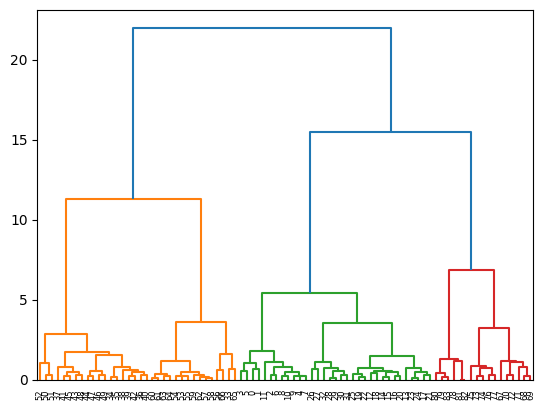

In [34]:
# Aglomerative Hierarachical clustering
from scipy.cluster.hierarchy import linkage,dendrogram
merging=linkage(X_scaled,method='ward')
dendrogram(merging);

In [35]:
#CLUSTERS BASED ON MERGINGS
from scipy.cluster.hierarchy import fcluster
cluster_labelss=fcluster(merging,t=4,criterion='maxclust') # t=number of clusters identified
cluster_labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1,
       3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4], dtype=int32)

In [36]:
from sklearn.cluster import AgglomerativeClustering
agg_hc=AgglomerativeClustering(n_clusters=4,
                               metric='euclidean',
                               linkage='ward')
agg_cluster=agg_hc.fit_predict(X_scaled)
agg_cluster

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [37]:
df['agg_cluster']=agg_cluster
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width,kmeans_cluster,agg_cluster
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8,0,2
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1,0,2
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3,0,2
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1,0,2
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2,0,2


In [38]:
df.kmeans_cluster.value_counts()

,count
kmeans_cluster,
0,34
1,20
3,13
2,11
4,6


In [39]:
df['agg_cluster'].value_counts()

,count
agg_cluster,
2,33
3,19
0,17
1,15


<Axes: xlabel='Weight', ylabel='Length2'>

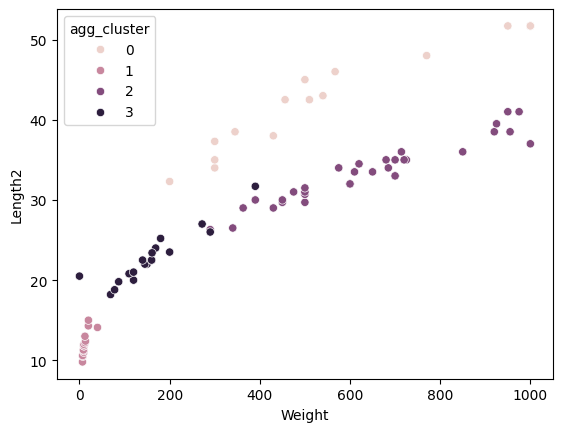

In [40]:
sns.scatterplot(data=df,x='Weight',y='Length2',hue='agg_cluster')

In [41]:
sil_scores={}
for i in range(2,11):
  agg_hc=AgglomerativeClustering(n_clusters=i,
                               metric='euclidean',
                               linkage='ward')
  sil_h=silhouette_score(X_scaled,agg_hc.fit_predict(X_scaled))
  sil_scores[i]=sil_h

In [42]:
  sil_scores

{2: np.float64(0.44029438983294655),
 3: np.float64(0.5317405959930687),
 4: np.float64(0.5642966948824016),
 5: np.float64(0.5794549380810812),
 6: np.float64(0.5103844656021281),
 7: np.float64(0.4852858619095591),
 8: np.float64(0.4915598261047463),
 9: np.float64(0.483147372485779),
 10: np.float64(0.47189013723685397)}

In [43]:
# DB scan clustering
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
# for e in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]:
db_scan = DBSCAN(eps=0.3, min_samples=5)
db_cluster=db_scan.fit_predict(X_scaled)
db_cluster

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1,  0,  0,  0, -1,  0,  0,  0, -1, -1,  0,  0, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [45]:
df['db_cluster']=db_cluster
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width,kmeans_cluster,agg_cluster,db_cluster
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8,0,2,-1
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1,0,2,-1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3,0,2,-1
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1,0,2,-1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2,0,2,-1


In [46]:
sil_scores={}
for i in range(2,11):
  db_hc=DBSCAN(eps=0.5,min_samples=5)
  sil_h=silhouette_score(X_scaled,db_hc.fit_predict(X_scaled))
  sil_scores[i]=sil_h
sil_scores

{2: np.float64(0.317448800570763),
 3: np.float64(0.317448800570763),
 4: np.float64(0.317448800570763),
 5: np.float64(0.317448800570763),
 6: np.float64(0.317448800570763),
 7: np.float64(0.317448800570763),
 8: np.float64(0.317448800570763),
 9: np.float64(0.317448800570763),
 10: np.float64(0.317448800570763)}